# EDA — HDFS Dataset

This notebook performs Exploratory Data Analysis on the HDFS dataset after preprocessing.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

# Plot styling
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print('Libraries loaded!')

Libraries loaded!


## 1. Load Data

In [10]:
# Load preprocessed files


train_df = pd.read_csv('../data/HDFS/train.csv')
test_df  = pd.read_csv('../data/HDFS/test.csv')


# Combine for full EDA
df = pd.concat([train_df, test_df]).reset_index(drop=True)

print(f'Train set : {len(train_df):,} rows')
print(f'Test set  : {len(test_df):,} rows')
print(f'Total     : {len(df):,} rows')
print(f'\nColumns: {list(df.columns)}')

Train set : 446,578 rows
Test set  : 128,483 rows
Total     : 575,061 rows

Columns: ['block_id', 'log_paragraph', 'num_lines', 'label']


In [11]:
# Quick peek
df.head(3)

,block_id,log_paragraph,num_lines,label
0,blk_-1608999687919862906,dfs.DataNode$DataXceiver: Receiving block blk_...,279,0
1,blk_7503483334202473044,dfs.DataNode$DataXceiver: Receiving block blk_...,25,0
2,blk_-9073992586687739851,dfs.DataNode$DataXceiver: Receiving block blk_...,25,0


## 2. Dataset Overview

In [12]:
normal_count  = len(df[df['label'] == 0])
anomaly_count = len(df[df['label'] == 1])
total         = len(df)

print('=' * 45)
print('  HDFS Dataset Overview')
print('=' * 45)
print(f'  Total sessions   : {total:,}')
print(f'  Normal sessions  : {normal_count:,}')
print(f'  Anomaly sessions : {anomaly_count:,}')
print(f'  Anomaly ratio    : {anomaly_count/total*100:.2f}%')
print()
print('  Paper reports ~2.90% anomaly ratio -> verify above matches!')

  HDFS Dataset Overview
  Total sessions   : 575,061
  Normal sessions  : 558,223
  Anomaly sessions : 16,838
  Anomaly ratio    : 2.93%

  Paper reports ~2.90% anomaly ratio -> verify above matches!


## 3. Class Distribution

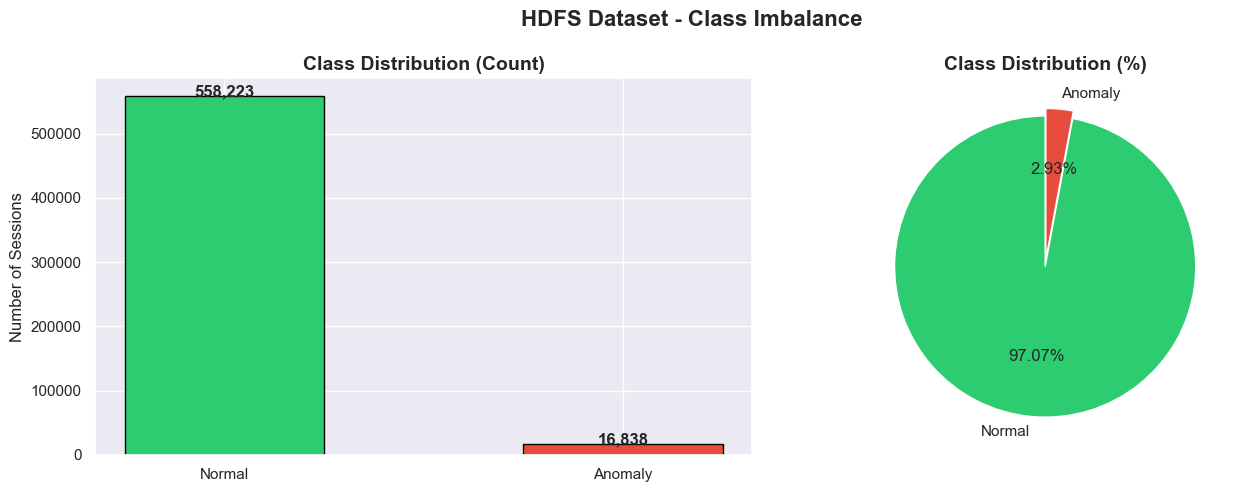

Note: Heavy class imbalance - this is why F1 score is used as main metric!


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
labels = ['Normal', 'Anomaly']
counts = [normal_count, anomaly_count]
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(labels, counts, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Sessions')
for i, v in enumerate(counts):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    counts,
    labels=labels,
    colors=colors,
    autopct='%1.2f%%',
    startangle=90,
    explode=(0, 0.05)
)
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('HDFS Dataset - Class Imbalance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('hdfs_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Note: Heavy class imbalance - this is why F1 score is used as main metric!')

## 4. Session Length Analysis

In [14]:
# Add word count and character count columns
df['word_count'] = df['log_paragraph'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['log_paragraph'].apply(lambda x: len(str(x)))

# Stats per class
print('Session Length Stats (word count):')
print(df.groupby('label')['word_count'].describe().round(2))
print()
print('Session Length Stats (num_lines):')
print(df.groupby('label')['num_lines'].describe().round(2))

Session Length Stats (word count):
          count    mean     std    min    25%    50%    75%     max
label                                                              
0      558223.0  178.39   41.06  113.0  179.0  179.0  184.0  2339.0
1       16838.0  159.22  117.14   13.0   32.0  192.0  248.0  2240.0

Session Length Stats (num_lines):
          count   mean    std   min   25%   50%   75%    max
label                                                       
0      558223.0  21.95   5.60  13.0  22.0  22.0  23.0  310.0
1       16838.0  19.23  14.04   2.0   4.0  23.0  30.0  297.0


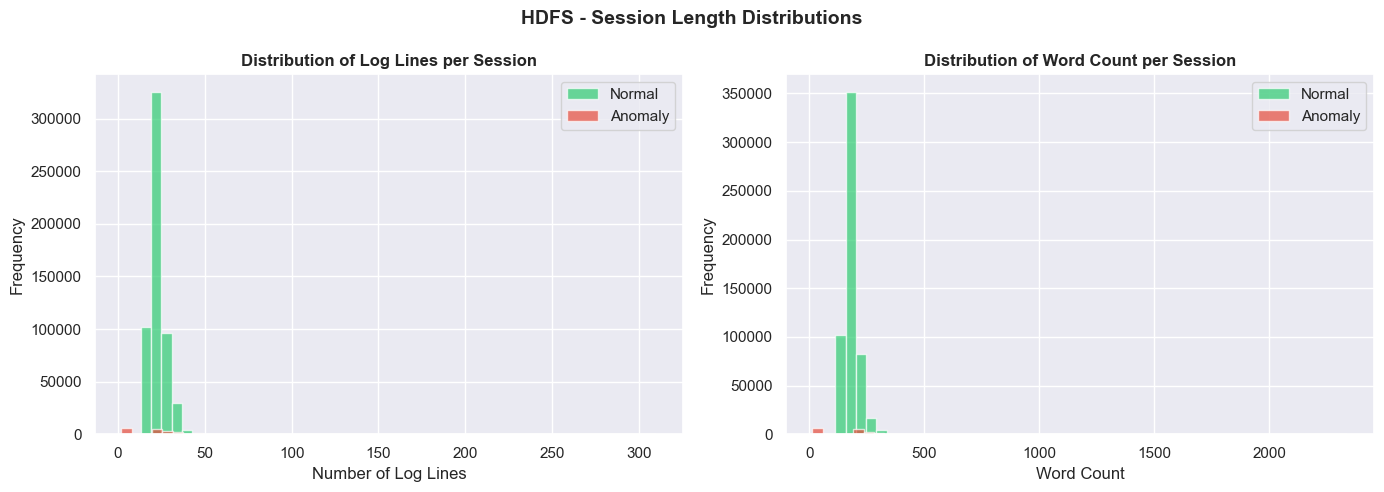

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normal_df  = df[df['label'] == 0]
anomaly_df = df[df['label'] == 1]

# Distribution of number of log lines per session
axes[0].hist(normal_df['num_lines'],  bins=50, alpha=0.7, color='#2ecc71', label='Normal')
axes[0].hist(anomaly_df['num_lines'], bins=50, alpha=0.7, color='#e74c3c', label='Anomaly')
axes[0].set_title('Distribution of Log Lines per Session', fontweight='bold')
axes[0].set_xlabel('Number of Log Lines')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Distribution of word count per session
axes[1].hist(normal_df['word_count'],  bins=50, alpha=0.7, color='#2ecc71', label='Normal')
axes[1].hist(anomaly_df['word_count'], bins=50, alpha=0.7, color='#e74c3c', label='Anomaly')
axes[1].set_title('Distribution of Word Count per Session', fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('HDFS - Session Length Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hdfs_session_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\shriy\AppData\Local\Temp\ipykernel_6768\720042559.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Normal', 'Anomaly'], patch_artist=True)


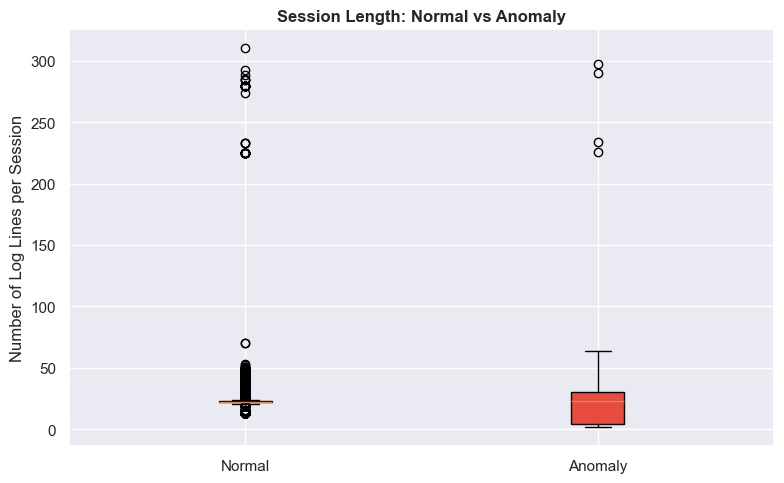

Are anomalous sessions longer or shorter than normal?
  Normal  avg lines: 22.0
  Anomaly avg lines: 19.2


In [17]:
# Boxplot comparison - normal vs anomaly session lengths
fig, ax = plt.subplots(figsize=(8, 5))

data_to_plot = [
    normal_df['num_lines'].values,
    anomaly_df['num_lines'].values
]

bp = ax.boxplot(data_to_plot, labels=['Normal', 'Anomaly'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')

ax.set_title('Session Length: Normal vs Anomaly', fontweight='bold')
ax.set_ylabel('Number of Log Lines per Session')
plt.tight_layout()
plt.savefig('hdfs_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Are anomalous sessions longer or shorter than normal?')
print(f'  Normal  avg lines: {normal_df["num_lines"].mean():.1f}')
print(f'  Anomaly avg lines: {anomaly_df["num_lines"].mean():.1f}')

## 5. Token Length Analysis
Important for LogFiT — need to know if RoBERTa (512 tokens) or Longformer (4096 tokens) should be used

In [21]:
from transformers import RobertaTokenizer

print('Loading RoBERTa tokenizer...')
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

# Tokenize a sample (full dataset takes too long, sample 1000)
sample_df = df.sample(min(1000, len(df)), random_state=42)
print(f'Tokenizing {len(sample_df)} sample paragraphs...')

sample_df = sample_df.copy()
sample_df['token_count'] = sample_df['log_paragraph'].apply(
    lambda x: len(tokenizer.encode(str(x), truncation=False))
)

print(f'\nToken Count Statistics (sample of {len(sample_df)}):')
print(sample_df['token_count'].describe().round(2))
print(f'\n0.8 quantile (LogFiT heuristic threshold): {sample_df["token_count"].quantile(0.8):.0f} tokens')
print(f'-> LogFiT will use: {"RoBERTa" if sample_df["token_count"].quantile(0.8) <= 512 else "Longformer"}')

c:\Users\shriy\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading RoBERTa tokenizer...


c:\Users\shriy\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\shriy\.cache\huggingface\hub\models--roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Token indices sequence length is longer than the specified maximum sequence length for this model (117

Tokenizing 1000 sample paragraphs...

Token Count Statistics (sample of 1000):
count    1000.00
mean     1012.58
std       262.66
min       111.00
25%       999.75
50%      1025.00
75%      1080.25
max      1824.00
Name: token_count, dtype: float64

0.8 quantile (LogFiT heuristic threshold): 1178 tokens
-> LogFiT will use: Longformer


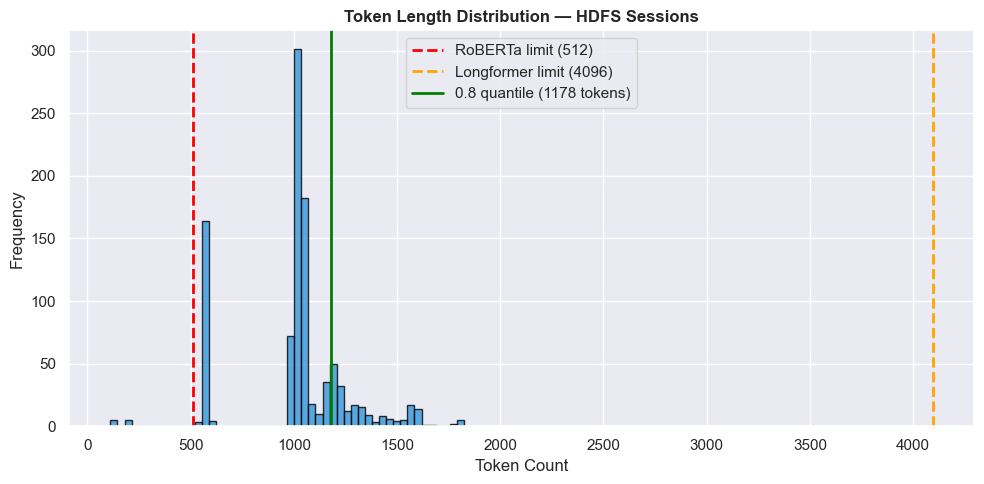

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(sample_df['token_count'], bins=50, color='#3498db', edgecolor='black', alpha=0.8)
ax.axvline(x=512,  color='red',    linestyle='--', linewidth=2, label='RoBERTa limit (512)')
ax.axvline(x=4096, color='orange', linestyle='--', linewidth=2, label='Longformer limit (4096)')
ax.axvline(
    x=sample_df['token_count'].quantile(0.8),
    color='green', linestyle='-', linewidth=2,
    label=f'0.8 quantile ({sample_df["token_count"].quantile(0.8):.0f} tokens)'
)

ax.set_title('Token Length Distribution — HDFS Sessions', fontweight='bold')
ax.set_xlabel('Token Count')
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.savefig('hdfs_token_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Log Content Analysis

In [23]:
# Most common words in normal vs anomaly logs
def get_top_words(texts, n=20):
    all_words = []
    for text in texts:
        words = re.findall(r'[a-zA-Z]+', str(text).lower())
        all_words.extend(words)
    # Filter common stopwords
    stopwords = {'for', 'the', 'to', 'of', 'in', 'is', 'a', 'an', 'and', 'or', 'blk', 'src', 'dest'}
    words = [w for w in all_words if w not in stopwords and len(w) > 2]
    return Counter(words).most_common(n)

print('Top 15 words in NORMAL logs:')
normal_words = get_top_words(normal_df['log_paragraph'].sample(min(500, len(normal_df))))
for word, count in normal_words[:15]:
    print(f'  {word:<25} {count:,}')

print('\nTop 15 words in ANOMALY logs:')
anomaly_words = get_top_words(anomaly_df['log_paragraph'].sample(min(500, len(anomaly_df))))
for word, count in anomaly_words[:15]:
    print(f'  {word:<25} {count:,}')

Top 15 words in NORMAL logs:
  dfs                       13,376
  block                     10,517
  datanode                  5,101
  packetresponder           4,500
  fsnamesystem              3,230
  namesystem                3,230
  size                      3,000
  added                     2,730
  fsdataset                 2,460
  deleting                  2,460
  file                      2,460
  mnt                       2,460
  hadoop                    2,460
  data                      2,460
  current                   2,460

Top 15 words in ANOMALY logs:
  dfs                       11,820
  block                     9,232
  datanode                  4,521
  packetresponder           2,889
  fsnamesystem              2,883
  namesystem                2,748
  size                      2,385
  fsdataset                 2,304
  file                      2,199
  added                     2,178
  deleting                  2,158
  mnt                       2,158
  hadoop           

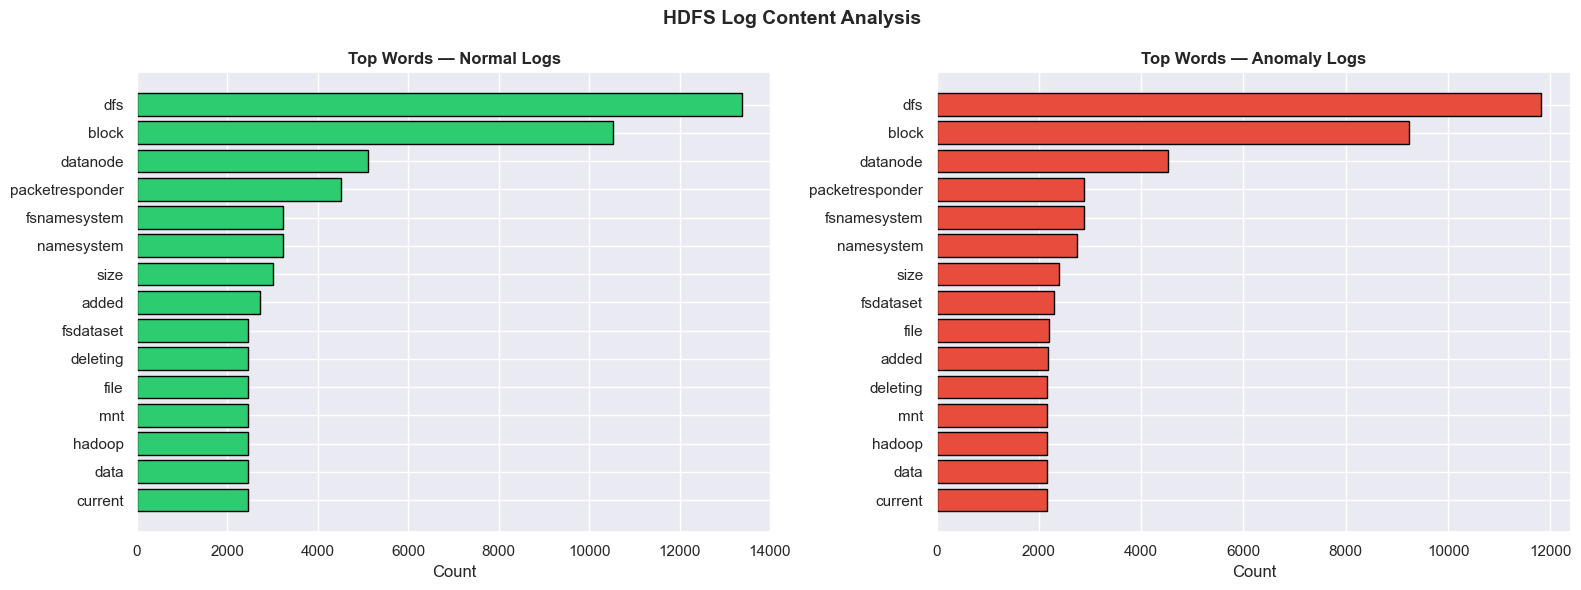

In [25]:
# Top words bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Normal
words_n, counts_n = zip(*normal_words[:15])
axes[0].barh(words_n, counts_n, color='#2ecc71', edgecolor='black')
axes[0].set_title('Top Words — Normal Logs', fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

# Anomaly
words_a, counts_a = zip(*anomaly_words[:15])
axes[1].barh(words_a, counts_a, color='#e74c3c', edgecolor='black')
axes[1].set_title('Top Words — Anomaly Logs', fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()

plt.suptitle('HDFS Log Content Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hdfs_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Train/Test Split Verification

In [30]:
print('Train Set:')
print(f'  Total rows     : {len(train_df):,}')
print(f'  Normal         : {len(train_df[train_df["label"]==0]):,}')
print(f'  Anomaly        : {len(train_df[train_df["label"]==1]):,}')
print(f'  (should be 0 anomalies in train - self supervised!)')

print('\nTest Set:')
test_anomaly = len(test_df[test_df['label']==1])
print(f'  Total rows     : {len(test_df):,}')
print(f'  Normal         : {len(test_df[test_df["label"]==0]):,}')
print(f'  Anomaly        : {test_anomaly:,}')
print(f'  Anomaly ratio  : {test_anomaly/len(test_df)*100:.2f}%')

Train Set:
  Total rows     : 446,578
  Normal         : 446,578
  Anomaly        : 0
  (should be 0 anomalies in train - self supervised!)

Test Set:
  Total rows     : 128,483
  Normal         : 111,645
  Anomaly        : 16,838
  Anomaly ratio  : 13.11%


## 8. Sample Log Paragraphs

In [27]:
print('=' * 60)
print('SAMPLE NORMAL LOG PARAGRAPH')
print('=' * 60)
sample = normal_df.sample(1).iloc[0]
print(f'Block ID  : {sample["block_id"]}')
print(f'Num lines : {sample["num_lines"]}')
print(f'Paragraph :\n{sample["log_paragraph"][:500]}')

print('\n' + '=' * 60)
print('SAMPLE ANOMALY LOG PARAGRAPH')
print('=' * 60)
sample = anomaly_df.sample(1).iloc[0]
print(f'Block ID  : {sample["block_id"]}')
print(f'Num lines : {sample["num_lines"]}')
print(f'Paragraph :\n{sample["log_paragraph"][:500]}')

SAMPLE NORMAL LOG PARAGRAPH
Block ID  : blk_-1905248584328223434
Num lines : 34
Paragraph :
dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: /user/root/randtxt/_temporary/_task_200811092030_0003_m_000718_0/part-00718. blk_-1905248584328223434 dfs.DataNode$DataXceiver: Receiving block blk_-1905248584328223434 src: /10.251.71.240:50768 dest: /10.251.71.240:50010 dfs.DataNode$DataXceiver: Receiving block blk_-1905248584328223434 src: /10.250.13.188:33239 dest: /10.250.13.188:50010 dfs.DataNode$DataXceiver: Receiving block blk_-1905248584328223434 src: /10.251.71.240:58487 dest: /10.251.

SAMPLE ANOMALY LOG PARAGRAPH
Block ID  : blk_-4726707423776056173
Num lines : 4
Paragraph :
dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: /user/root/randtxt/_temporary/_task_200811092030_0003_m_000396_0/part-00396. blk_-4726707423776056173 dfs.DataNode$DataXceiver: Receiving block blk_-4726707423776056173 src: /10.251.39.160:38000 dest: /10.251.39.160:50010 dfs.DataNode$DataXceiver: Receiving block

## 9. Summary — Key Findings

In [28]:
print('=' * 55)
print('  HDFS EDA Summary')
print('=' * 55)
print(f'  Total sessions         : {len(df):,}')
print(f'  Anomaly ratio          : {anomaly_count/total*100:.2f}%')
print(f'  Avg lines/session      : {df["num_lines"].mean():.1f}')
print(f'  Avg words/session      : {df["word_count"].mean():.1f}')
print(f'  0.8 quantile tokens    : {sample_df["token_count"].quantile(0.8):.0f}')
print(f'  Model to use           : {"RoBERTa" if sample_df["token_count"].quantile(0.8) <= 512 else "Longformer"}')
print(f'  Class imbalance        : Yes - F1 score used as main metric')
print('=' * 55)

  HDFS EDA Summary
  Total sessions         : 575,061
  Anomaly ratio          : 2.93%
  Avg lines/session      : 21.9
  Avg words/session      : 177.8
  0.8 quantile tokens    : 1178
  Model to use           : Longformer
  Class imbalance        : Yes - F1 score used as main metric


In [29]:
# Check separately
print("FULL dataset:")
print(f"  Normal  : {len(df[df['label']==0]):,}")
print(f"  Anomaly : {len(df[df['label']==1]):,}")
print(f"  Ratio   : {len(df[df['label']==1])/len(df)*100:.2f}%")

print("\nTEST set only:")
print(f"  Normal  : {len(test_df[test_df['label']==0]):,}")
print(f"  Anomaly : {len(test_df[test_df['label']==1]):,}")
print(f"  Ratio   : {len(test_df[test_df['label']==1])/len(test_df)*100:.2f}%")

print("\nTRAIN set only:")
print(f"  Normal  : {len(train_df[train_df['label']==0]):,}")
print(f"  Anomaly : {len(train_df[train_df['label']==1]):,}")

FULL dataset:
  Normal  : 558,223
  Anomaly : 16,838
  Ratio   : 2.93%

TEST set only:
  Normal  : 111,645
  Anomaly : 16,838
  Ratio   : 13.11%

TRAIN set only:
  Normal  : 446,578
  Anomaly : 0
